<a href="https://colab.research.google.com/github/yerim0829/ED-Overcrowding-Prediction/blob/code/emergency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import requests
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, Dense
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [ ]:
er = pd.read_csv("/content/ER_3hour_timeseries.csv")
er["datetime"] = pd.to_datetime(er["datetime"])
er = er.set_index("datetime")
er.head()


FileNotFoundError: [Errno 2] No such file or directory: '/content/ER_3hour_timeseries.csv'

In [ ]:
asos_list = []
for year in range(2019, 2023):
    df = pd.read_csv(f"/content/ASOS_{year}.csv")
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    asos_list.append(df)

asos = pd.concat(asos_list).sort_index()
asos_3h = asos.resample("3H").ffill()
asos_3h.head()


,station,TA,Tmin,Tmax
date,,,,
2019-01-01 00:00:00,108,-5.0,-8.2,-0.6
2019-01-01 03:00:00,108,-5.0,-8.2,-0.6
2019-01-01 06:00:00,108,-5.0,-8.2,-0.6
2019-01-01 09:00:00,108,-5.0,-8.2,-0.6
2019-01-01 12:00:00,108,-5.0,-8.2,-0.6


In [ ]:
API_KEY = "8f5d544a348b4f71d8c8e8e36b13cd223928006737e5986b8dc1ccc63e71bdd3"

def get_holidays(api_key, year):
    url = "https://apis.data.go.kr/B090041/openapi/service/SpcdeInfoService/getHoliDeInfo"
    params = {"serviceKey": api_key, "solYear": year, "numOfRows": 100, "_type": "json"}

    r = requests.get(url, params=params).json()

    items = r["response"]["body"].get("items")
    if not items:
        return pd.DataFrame(columns=["datetime", "holiday"])

    df = pd.DataFrame(items["item"])
    df["datetime"] = pd.to_datetime(df["locdate"].astype(str))
    df["holiday"] = 1
    return df[["datetime", "holiday"]]

holiday_list = []
for year in range(2020, 2024):
    holiday_list.append(get_holidays(API_KEY, year))

holidays = pd.concat(holiday_list).set_index("datetime").resample("3H").max().fillna(0)
holidays.head()


,holiday
datetime,
2020-01-01 00:00:00,1.0
2020-01-01 03:00:00,0.0
2020-01-01 06:00:00,0.0
2020-01-01 09:00:00,0.0
2020-01-01 12:00:00,0.0


In [ ]:
df = (
    er.merge(asos_3h, left_index=True, right_index=True, how="left")
      .merge(holidays, left_index=True, right_index=True, how="left")
)

df = df.ffill().bfill()
df.head()


,count,station,TA,Tmin,Tmax,holiday
datetime,,,,,,
2020-01-01 00:00:00,229.167300,108.0,-2.2,-6.5,0.3,1.0
2020-01-01 03:00:00,146.966725,108.0,-2.2,-6.5,0.3,0.0
2020-01-01 06:00:00,202.769656,108.0,-2.2,-6.5,0.3,0.0
2020-01-01 09:00:00,428.495028,108.0,-2.2,-6.5,0.3,0.0
2020-01-01 12:00:00,398.494317,108.0,-2.2,-6.5,0.3,0.0


In [ ]:
df["count_shift_plus"]  = df["count"].shift(1).bfill()
df["count_shift_minus"] = df["count"].shift(-1).ffill()
df["roll_mean"]         = df["count"].rolling(5, min_periods=1).mean()
df["roll_std"]          = df["count"].rolling(5, min_periods=1).std().fillna(0)

df.head()


,count,station,TA,Tmin,Tmax,holiday,count_shift_plus,count_shift_minus,roll_mean,roll_std
datetime,,,,,,,,,,
2020-01-01 00:00:00,229.167300,108.0,-2.2,-6.5,0.3,1.0,229.167300,146.966725,229.167300,0.000000
2020-01-01 03:00:00,146.966725,108.0,-2.2,-6.5,0.3,0.0,229.167300,202.769656,188.067012,58.124585
2020-01-01 06:00:00,202.769656,108.0,-2.2,-6.5,0.3,0.0,146.966725,428.495028,192.967894,41.967721
2020-01-01 09:00:00,428.495028,108.0,-2.2,-6.5,0.3,0.0,202.769656,398.494317,251.849677,122.647669
2020-01-01 12:00:00,398.494317,108.0,-2.2,-6.5,0.3,0.0,428.495028,380.576057,281.178605,124.830958


In [ ]:
target = df["count"].values
features = df.drop(columns=["count"]).values

scaler = MinMaxScaler()
scaled = scaler.fit_transform(features)

X, y = [], []
window = 12  # 36시간 window

for i in range(len(df) - window):
    X.append(scaled[i:i+window])
    y.append(target[i+window])

X = np.array(X)
y = np.array(y)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [ ]:
model = Sequential([
    Conv1D(64, kernel_size=3, activation="relu", input_shape=(window, X.shape[2])),
    LSTM(64),
    Dense(1)
])

model.compile(optimizer="adam", loss="mae")
model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=1)

pred_lstm = model.predict(X_test).flatten()


Epoch 1/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 320.1136
Epoch 2/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 293.7588
Epoch 3/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 270.7438
Epoch 4/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 244.9968
Epoch 5/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 221.3576
Epoch 6/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 200.4623
Epoch 7/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 177.6405
Epoch 8/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 159.4297
Epoch 9/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 146.0633
Epoch 10/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 135.6325
Epoch 11/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 125.3478
Epoch 12/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 119.2254
Epoch 13/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 113.8264
Epoch 14/15
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 109.9779
Epoch 15/15
366/366 ━━━━

In [ ]:
flat_train = scaled[:-window][:train_size]
flat_test  = scaled[:-window][train_size:]

xgb_model = xgb.XGBRegressor()
xgb_model.fit(flat_train, y_train)
pred_xgb = xgb_model.predict(flat_test)

rf_model = RandomForestRegressor(n_estimators=300)
rf_model.fit(flat_train, y_train)
pred_rf = rf_model.predict(flat_test)


In [ ]:
def eval_model(true, pred):
    return {
        "MAE": mean_absolute_error(true, pred),
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "R2": r2_score(true, pred)
    }

print("CNN-LSTM:", eval_model(y_test, pred_lstm))
print("XGBoost:", eval_model(y_test, pred_xgb))
print("RandomForest:", eval_model(y_test, pred_rf))


CNN-LSTM: {'MAE': 75.88577135468879, 'RMSE': np.float64(100.06033459245779), 'R2': -0.9326926509885831}
XGBoost: {'MAE': 171.37527565827864, 'RMSE': np.float64(189.60049430904024), 'R2': -5.939334527165877}
RandomForest: {'MAE': 201.41540819538798, 'RMSE': np.float64(214.8017548185639), 'R2': -7.906653225566888}


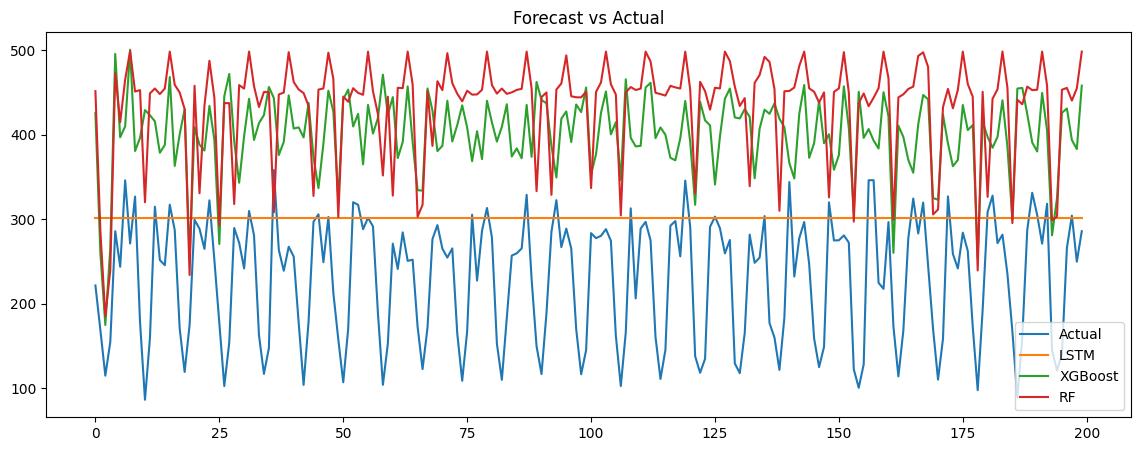

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(y_test[:200], label="Actual")
plt.plot(pred_lstm[:200], label="LSTM")
plt.plot(pred_xgb[:200], label="XGBoost")
plt.plot(pred_rf[:200], label="RF")
plt.legend()
plt.title("Forecast vs Actual")
plt.show()


###모델 고도화 !!(최최최종)

Epoch 1/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 285.6353
Epoch 2/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 98.5675
Epoch 3/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 92.0332
Epoch 4/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 94.4634
Epoch 5/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 92.1599
Epoch 6/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 93.0479
Epoch 7/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 93.8249
Epoch 8/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 92.8698
Epoch 9/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 91.8329
Epoch 10/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 92.6182
Epoch 11/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 93.0326
Epoch 12/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 92.3730
Epoch 13/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 92.7641
Epoch 14/50
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 60.0867
Epoch 15/50
366/366 ━━━━━━━━━━━━━━━━━━

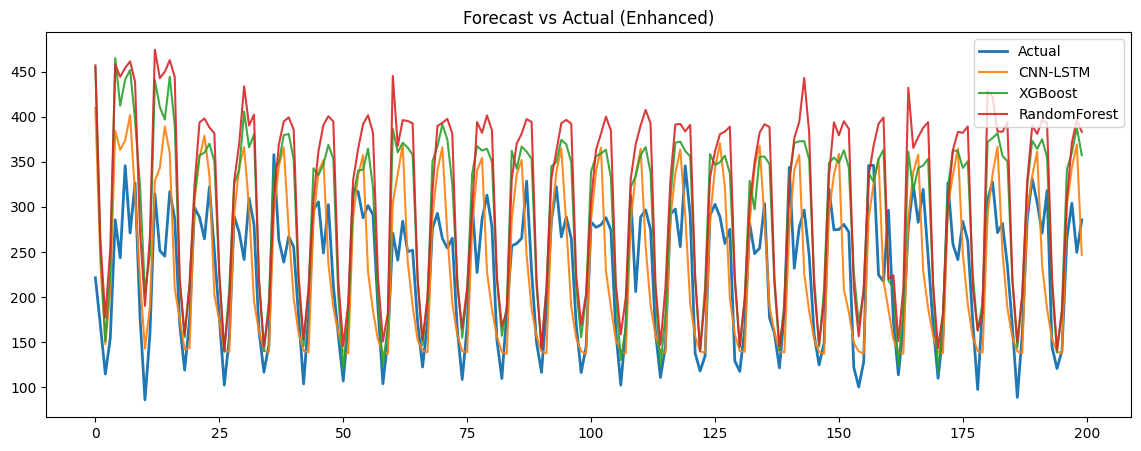

In [ ]:
# ============================================================
# 1. 라이브러리 로드
# ============================================================
import pandas as pd
import numpy as np
import requests
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Conv1D, Dense, MaxPooling1D, Dropout
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 2. ER 데이터 읽기
# ============================================================
er = pd.read_csv("/content/ER_3hour_timeseries.csv")
er["datetime"] = pd.to_datetime(er["datetime"])
er = er.set_index("datetime")


# ============================================================
# 3. 기상 데이터 불러오기
# ============================================================
asos_list = []
for year in range(2019, 2023):
    df = pd.read_csv(f"/content/ASOS_{year}.csv")
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    asos_list.append(df)

asos = pd.concat(asos_list).sort_index()
asos_3h = asos.resample("3H").ffill()


# ============================================================
# 4. 공휴일 데이터 불러오기
# ============================================================
API_KEY = "8f5d544a348b4f71d8c8e8e36b13cd223928006737e5986b8dc1ccc63e71bdd3"

def get_holidays(api_key, year):
    url = "https://apis.data.go.kr/B090041/openapi/service/SpcdeInfoService/getHoliDeInfo"
    params = {"serviceKey": api_key, "solYear": year, "numOfRows": 100, "_type": "json"}
    r = requests.get(url, params=params).json()

    items = r["response"]["body"].get("items")
    if not items:
        return pd.DataFrame(columns=["datetime", "holiday"])

    df = pd.DataFrame(items["item"])
    df["datetime"] = pd.to_datetime(df["locdate"].astype(str))
    df["holiday"] = 1
    return df[["datetime", "holiday"]]

holiday_list = []
for year in range(2020, 2024):
    holiday_list.append(get_holidays(API_KEY, year))

holidays = pd.concat(holiday_list).set_index("datetime").resample("3H").max().fillna(0)


# ============================================================
# 5. 데이터 병합
# ============================================================
df = (
    er.merge(asos_3h, left_index=True, right_index=True, how="left")
      .merge(holidays, left_index=True, right_index=True, how="left")
)
df = df.ffill().bfill()


# ============================================================
# 6. Feature Engineering 강화
# ============================================================

# 시간 정보 Feature
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["weekend"] = (df["dayofweek"] >= 5).astype(int)

# Lag Features
lags = [1, 2, 6, 12, 24]
for lag in lags:
    df[f"lag_{lag}"] = df["count"].shift(lag)

# Rolling Stats
df["roll_mean_6"] = df["count"].rolling(6).mean()
df["roll_std_6"] = df["count"].rolling(6).std()
df["roll_max_6"] = df["count"].rolling(6).max()
df["roll_min_6"] = df["count"].rolling(6).min()

df = df.ffill().bfill()

df.head()


# ============================================================
# 7. Train/Test Split & Scaling
# ============================================================
target = df["count"].values
features = df.drop(columns=["count"]).values

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

window = 12
X, y = [], []

for i in range(len(df) - window):
    X.append(scaled_features[i:i+window])
    y.append(target[i+window])

X = np.array(X)
y = np.array(y)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# ============================================================
# 8. CNN-LSTM(2-layer) 모델
# ============================================================
model = Sequential([
    Conv1D(64, 3, activation="relu", padding="same", input_shape=(window, X.shape[2])),
    MaxPooling1D(),
    Conv1D(32, 3, activation="relu", padding="same"),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mae")
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

pred_lstm = model.predict(X_test).flatten()


# ============================================================
# 9. XGBoost 튜닝
# ============================================================
flat_train = scaled_features[:-window][:train_size]
flat_test  = scaled_features[:-window][train_size:]

xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_model.fit(flat_train, y_train)

pred_xgb = xgb_model.predict(flat_test)


# ============================================================
# 10. RandomForest 튜닝
# ============================================================
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)
rf_model.fit(flat_train, y_train)

pred_rf = rf_model.predict(flat_test)


# ============================================================
# 11. 성능 평가함수
# ============================================================
def eval_model(true, pred):
    return {
        "MAE": mean_absolute_error(true, pred),
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "R2": r2_score(true, pred)
    }

print("CNN-LSTM:", eval_model(y_test, pred_lstm))
print("XGBoost:", eval_model(y_test, pred_xgb))
print("RandomForest:", eval_model(y_test, pred_rf))


# ============================================================
# 12. 시각화 개선
# ============================================================
plt.figure(figsize=(14,5))
plt.plot(y_test[:200], label="Actual", linewidth=2)
plt.plot(pred_lstm[:200], label="CNN-LSTM", alpha=0.9)
plt.plot(pred_xgb[:200], label="XGBoost", alpha=0.9)
plt.plot(pred_rf[:200], label="RandomForest", alpha=0.9)
plt.legend()
plt.title("Forecast vs Actual (Enhanced)")
plt.show()


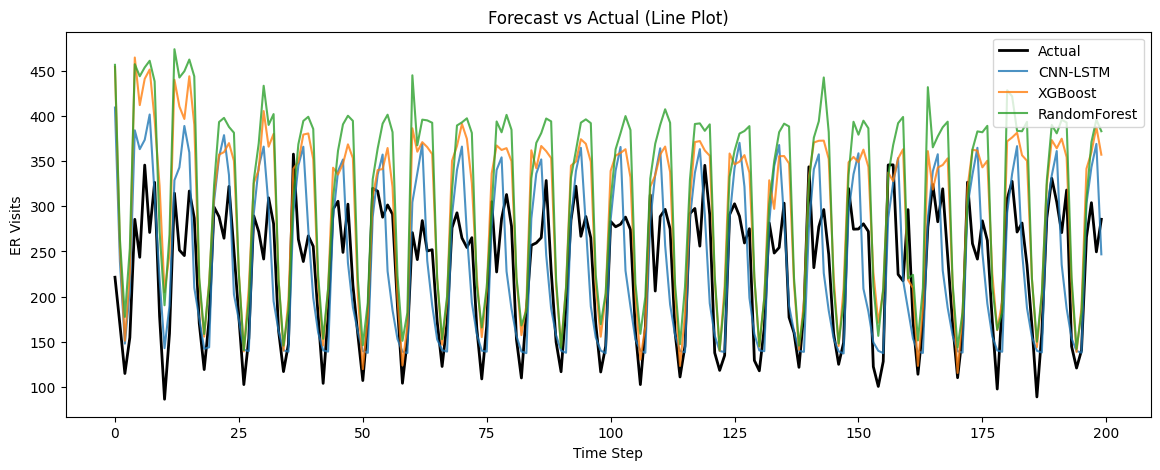

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(y_test[:200], label="Actual", linewidth=2, color='black')
plt.plot(pred_lstm[:200], label="CNN-LSTM", alpha=0.8)
plt.plot(pred_xgb[:200], label="XGBoost", alpha=0.8)
plt.plot(pred_rf[:200], label="RandomForest", alpha=0.8)
plt.legend()
plt.title("Forecast vs Actual (Line Plot)")
plt.xlabel("Time Step")
plt.ylabel("ER Visits")
plt.show()


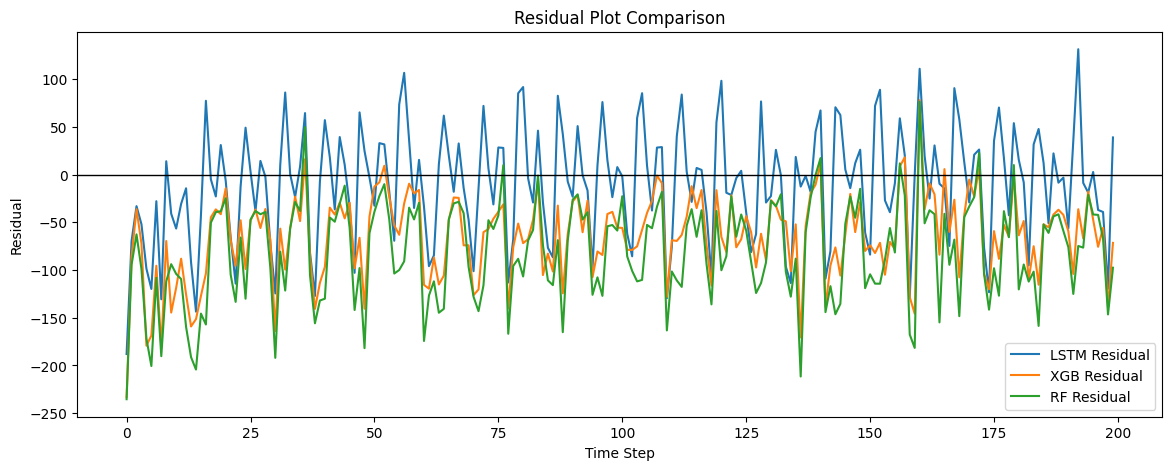

In [ ]:
#잔차 플롯
res_lstm = y_test - pred_lstm
res_xgb  = y_test - pred_xgb
res_rf   = y_test - pred_rf

plt.figure(figsize=(14,5))
plt.plot(res_lstm[:200], label="LSTM Residual")
plt.plot(res_xgb[:200], label="XGB Residual")
plt.plot(res_rf[:200], label="RF Residual")
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.title("Residual Plot Comparison")
plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.show()


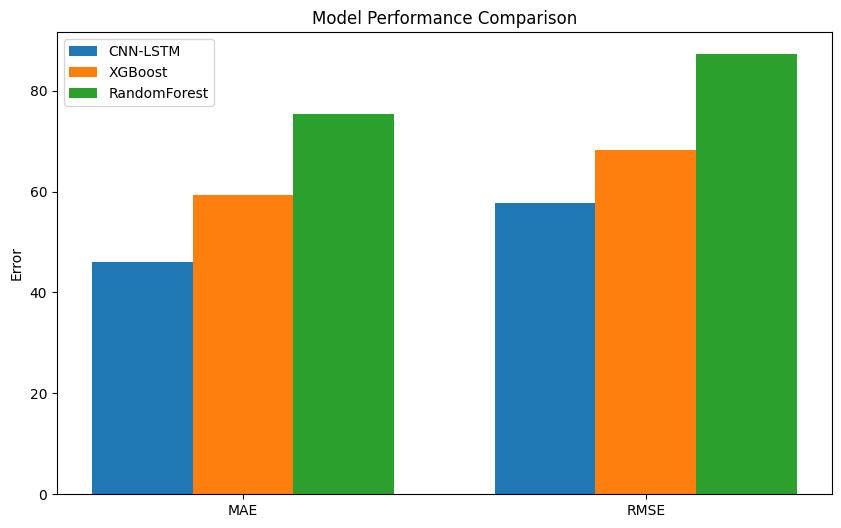

In [ ]:
#모델별 MAE/RMSE 바 차트

# Redefine eval_model function to ensure it's available in this cell's scope
def eval_model(true, pred):
    return {
        "MAE": mean_absolute_error(true, pred),
        "RMSE": np.sqrt(mean_squared_error(true, pred)),
        "R2": r2_score(true, pred)
    }

# Calculate metrics for each model and store them in individual variables
lstm_metrics = eval_model(y_test, pred_lstm)
lstm_mae = lstm_metrics["MAE"]
lstm_rmse = lstm_metrics["RMSE"]

xgb_metrics = eval_model(y_test, pred_xgb)
xgb_mae = xgb_metrics["MAE"]
xgb_rmse = xgb_metrics["RMSE"]

rf_metrics = eval_model(y_test, pred_rf)
rf_mae = rf_metrics["MAE"]
rf_rmse = rf_metrics["RMSE"]

metrics = ['MAE', 'RMSE']
lstm_vals = [lstm_mae, lstm_rmse]
xgb_vals  = [xgb_mae,  xgb_rmse]
rf_vals   = [rf_mae,   rf_rmse]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, lstm_vals, width, label='CNN-LSTM')
plt.bar(x, xgb_vals, width, label='XGBoost')
plt.bar(x + width, rf_vals, width, label='RandomForest')

plt.xticks(x, metrics)
plt.ylabel("Error")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

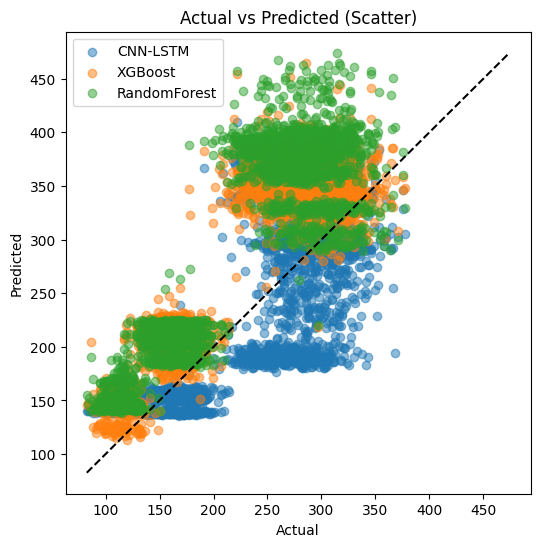

In [ ]:
#산점도 예측 vs. 실제
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_lstm, alpha=0.5, label="CNN-LSTM")
plt.scatter(y_test, pred_xgb, alpha=0.5, label="XGBoost")
plt.scatter(y_test, pred_rf, alpha=0.5, label="RandomForest")

# y=x 라인
min_val = min(y_test.min(), pred_lstm.min(), pred_xgb.min(), pred_rf.min())
max_val = max(y_test.max(), pred_lstm.max(), pred_xgb.max(), pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Scatter)")
plt.legend()
plt.show()


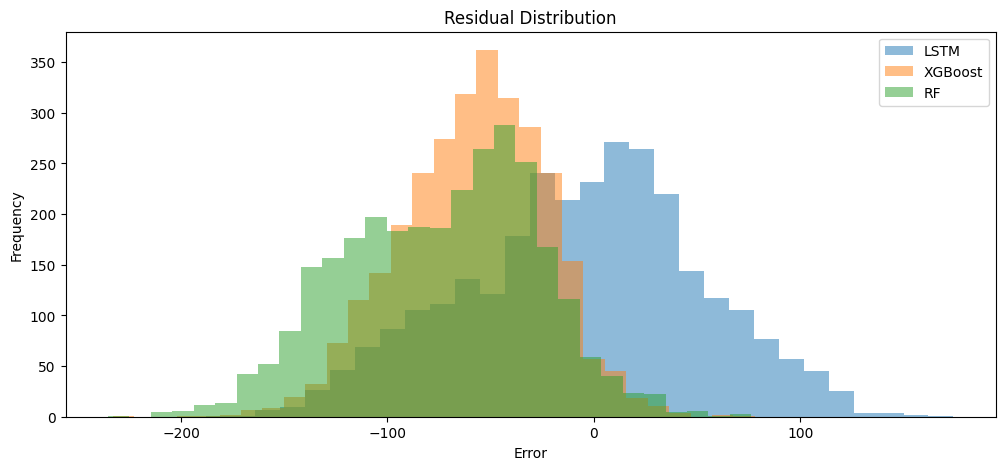

In [ ]:
#Error distribution(어떤 모델이 과대/과소 추정하는지)
plt.figure(figsize=(12,5))
plt.hist(res_lstm, bins=30, alpha=0.5, label="LSTM")
plt.hist(res_xgb, bins=30, alpha=0.5, label="XGBoost")
plt.hist(res_rf, bins=30, alpha=0.5, label="RF")

plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


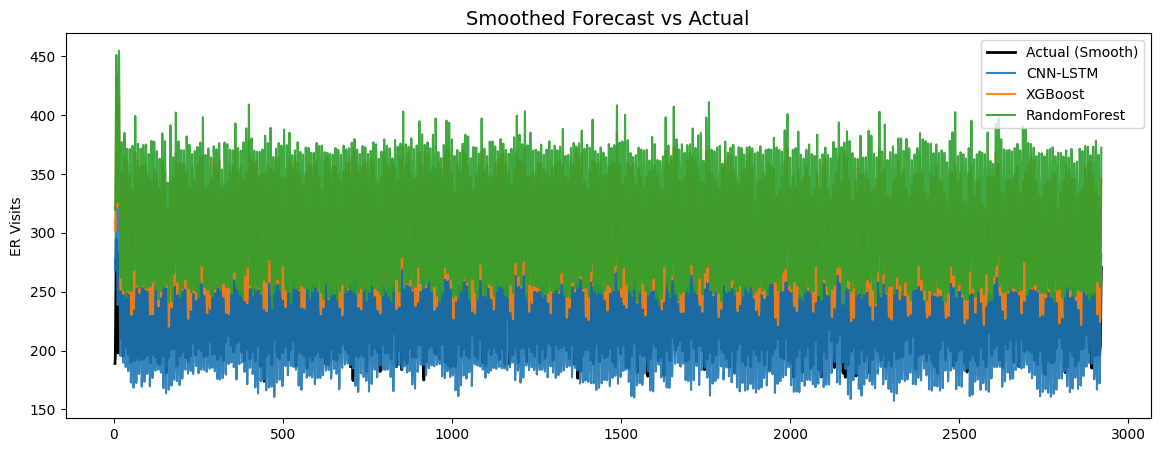

In [ ]:
plt.figure(figsize=(14,5))

# 이동평균 smoothing (window=5)
smooth_actual = pd.Series(y_test).rolling(5).mean()
smooth_lstm   = pd.Series(pred_lstm).rolling(5).mean()
smooth_xgb    = pd.Series(pred_xgb).rolling(5).mean()
smooth_rf     = pd.Series(pred_rf).rolling(5).mean()

plt.plot(smooth_actual, label="Actual (Smooth)", linewidth=2, color='black')
plt.plot(smooth_lstm, label="CNN-LSTM", alpha=0.9)
plt.plot(smooth_xgb, label="XGBoost", alpha=0.9)
plt.plot(smooth_rf, label="RandomForest", alpha=0.9)

plt.title("Smoothed Forecast vs Actual", fontsize=14)
plt.ylabel("ER Visits")
plt.legend()
plt.show()


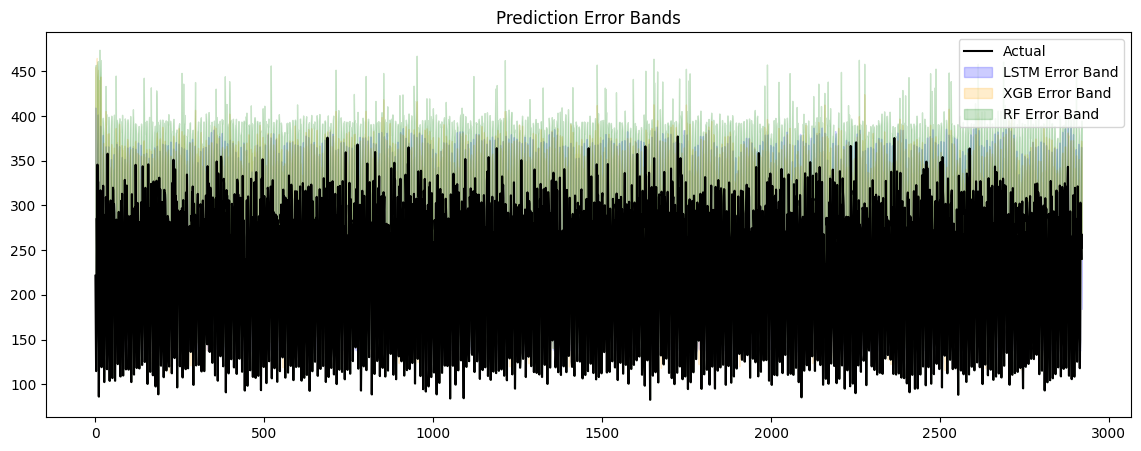

In [ ]:
plt.figure(figsize=(14,5))

error_lstm = pred_lstm - y_test
error_xgb  = pred_xgb - y_test
error_rf   = pred_rf - y_test

plt.plot(y_test, label="Actual", color="black")
plt.fill_between(range(len(y_test)), pred_lstm, y_test, color='blue', alpha=0.2, label='LSTM Error Band')
plt.fill_between(range(len(y_test)), pred_xgb, y_test, color='orange', alpha=0.2, label='XGB Error Band')
plt.fill_between(range(len(y_test)), pred_rf, y_test, color='green', alpha=0.2, label='RF Error Band')

plt.title("Prediction Error Bands")
plt.legend()
plt.show()


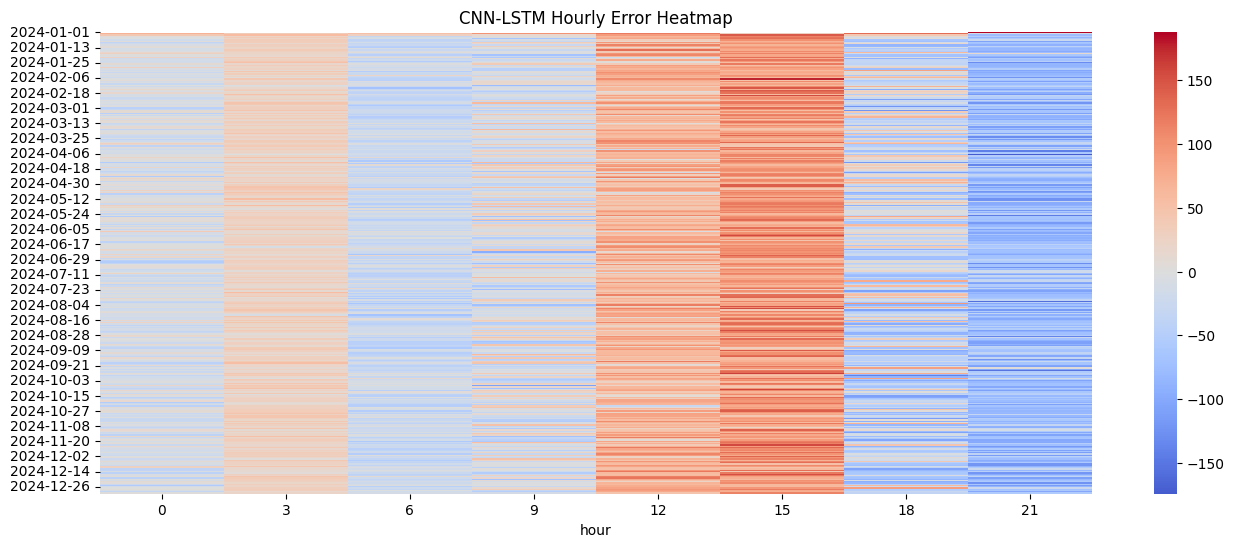

In [ ]:
#모델이 어떤 시간대에 약한지(Error Heatmap)
import seaborn as sns

df_heat = pd.DataFrame({
    "actual": y_test,
    "lstm": pred_lstm,
    "xgb": pred_xgb,
    "rf": pred_rf
})

df_heat["error_lstm"] = df_heat["lstm"] - df_heat["actual"]
df_heat["error_xgb"]  = df_heat["xgb"] - df_heat["actual"]
df_heat["error_rf"]   = df_heat["rf"] - df_heat["actual"]

# Datetime index 필요한 경우 y_test_index 로 사용
test_index = df.index[window + train_size:]
df_heat.index = pd.to_datetime(test_index)

df_heat["hour"] = df_heat.index.hour

pivot = df_heat.pivot_table(values="error_lstm", index=df_heat.index.date, columns="hour")

plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap="coolwarm", center=0)
plt.title("CNN-LSTM Hourly Error Heatmap")
plt.show()